# Comparing methods of hurricane forecast uncertainty
##### author: Elizabeth A. Barnes, Randal J. Barnes and Mark DeMaria

In [1]:
import datetime
import os
import pickle
import pprint
import time

import experiment_settings
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from build_data import build_hurricane_data
import build_model
from model_diagnostics import plot_history
from save_model_run import save_model_run
from sklearn import preprocessing
from training_instrumentation import TrainingInstrumentation
from silence_tensorflow import silence_tensorflow
import tensorflow_probability as tfp
import random
import imp

silence_tensorflow()

tf.config.set_visible_devices([], 'GPU') # turn-off tensorflow-metal if it is on

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "v1.0.1, 27 July 2022"

imp.reload(experiment_settings)
EXP_NAME_LIST = (
    "longitude301_EPCP48",
    "latitude301_EPCP48",
    "longitude302_EPCP48",
    "latitude302_EPCP48",
    "longitude303_EPCP48",
    "latitude303_EPCP48",    
)

OVERWRITE_MODEL = False
DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

## Start looping through runs

'longitude301_EPCP48_2013_shash3_network_seed_123_rng_seed_123'
saved_models/longitude301_EPCP48_2013_shash3_network_seed_123_rng_seed_123_weights.h5exists. Skipping...
'longitude301_EPCP48_2014_shash3_network_seed_123_rng_seed_123'
saved_models/longitude301_EPCP48_2014_shash3_network_seed_123_rng_seed_123_weights.h5exists. Skipping...
'longitude301_EPCP48_2015_shash3_network_seed_123_rng_seed_123'
saved_models/longitude301_EPCP48_2015_shash3_network_seed_123_rng_seed_123_weights.h5exists. Skipping...
'longitude301_EPCP48_2016_shash3_network_seed_123_rng_seed_123'
saved_models/longitude301_EPCP48_2016_shash3_network_seed_123_rng_seed_123_weights.h5exists. Skipping...
'longitude301_EPCP48_2017_shash3_network_seed_123_rng_seed_123'
saved_models/longitude301_EPCP48_2017_shash3_network_seed_123_rng_seed_123_weights.h5exists. Skipping...
'longitude301_EPCP48_2018_shash3_network_seed_123_rng_seed_123'
saved_models/longitude301_EPCP48_2018_shash3_network_seed_123_rng_seed_123_weights.h5exists

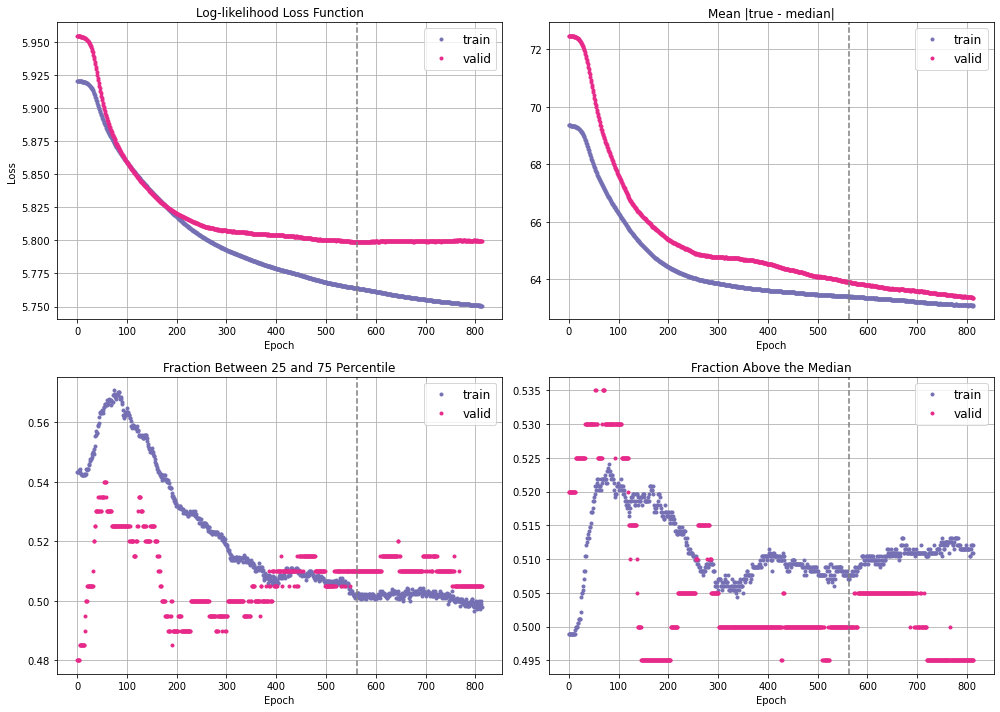

'longitude303_EPCP48_2014_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 365.
Epoch 00615: early stopping
{'best_epoch': 364,
 'elapsed_time': 12.06705617904663,
 'loss_train': 5.82230806350708,
 'loss_valid': 5.8584160804748535,
 'network_seed': 123}


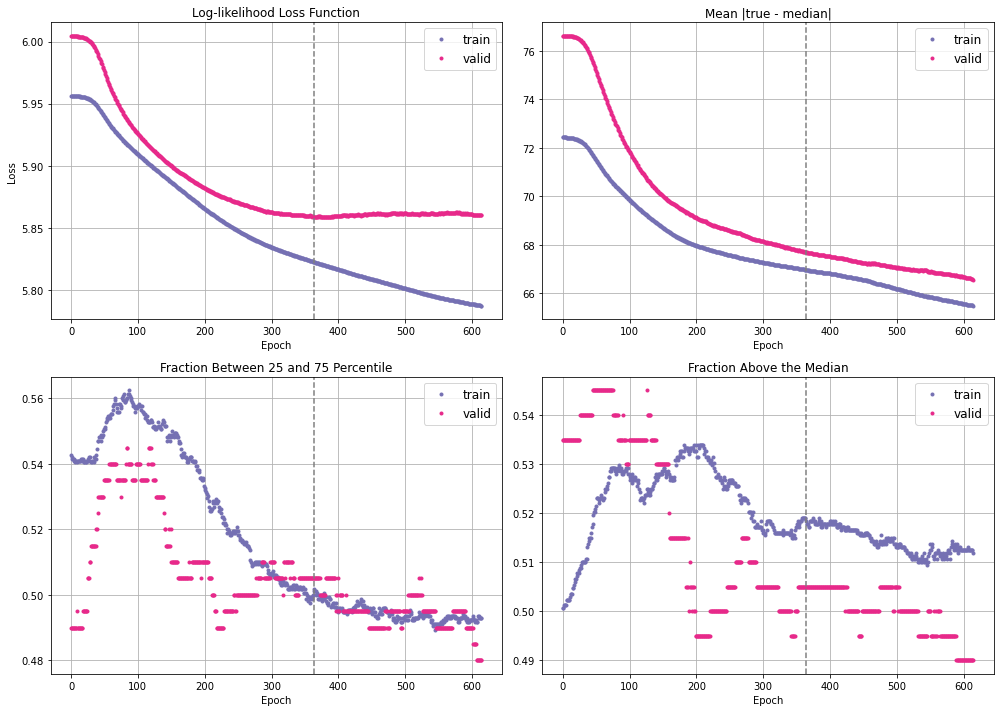

'longitude303_EPCP48_2015_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 3699.
Epoch 03949: early stopping
{'best_epoch': 3698,
 'elapsed_time': 71.65807604789734,
 'loss_train': 5.650278091430664,
 'loss_valid': 5.68486213684082,
 'network_seed': 123}


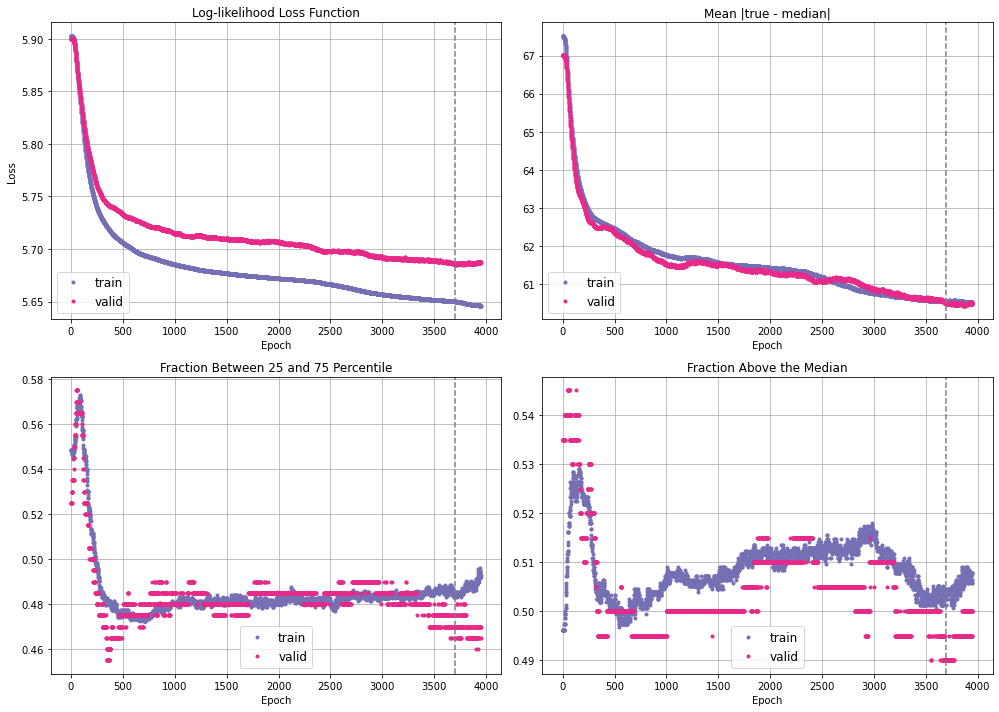

'longitude303_EPCP48_2016_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 669.
Epoch 00919: early stopping
{'best_epoch': 668,
 'elapsed_time': 18.00029492378235,
 'loss_train': 5.793339252471924,
 'loss_valid': 5.828944683074951,
 'network_seed': 123}


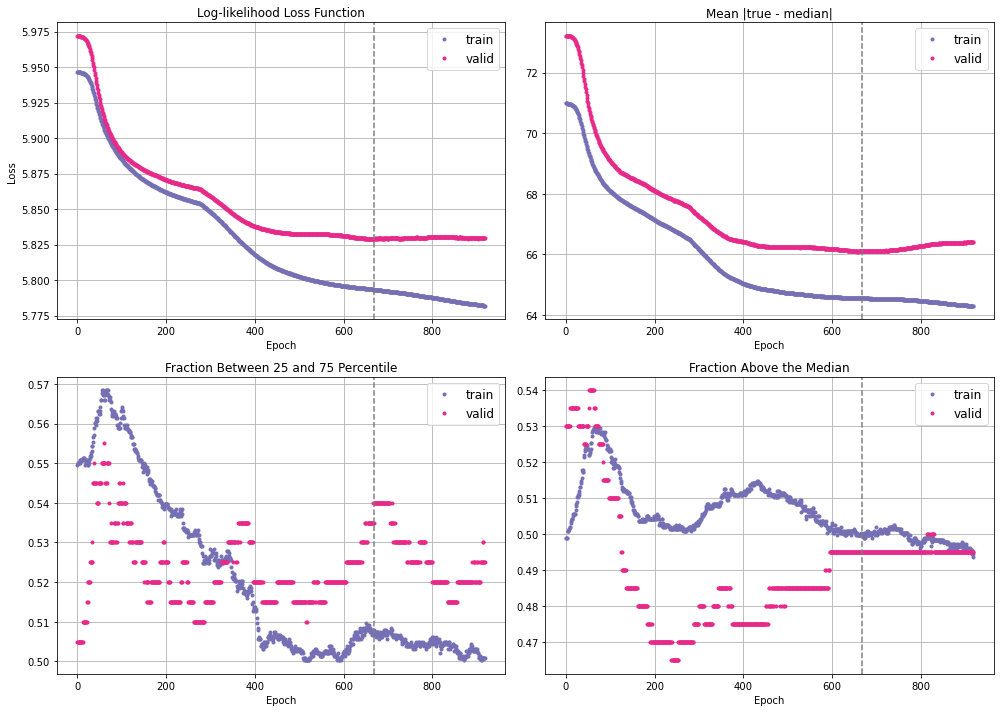

'longitude303_EPCP48_2017_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1493.
Epoch 01743: early stopping
{'best_epoch': 1492,
 'elapsed_time': 34.449110984802246,
 'loss_train': 5.761837482452393,
 'loss_valid': 5.841335296630859,
 'network_seed': 123}


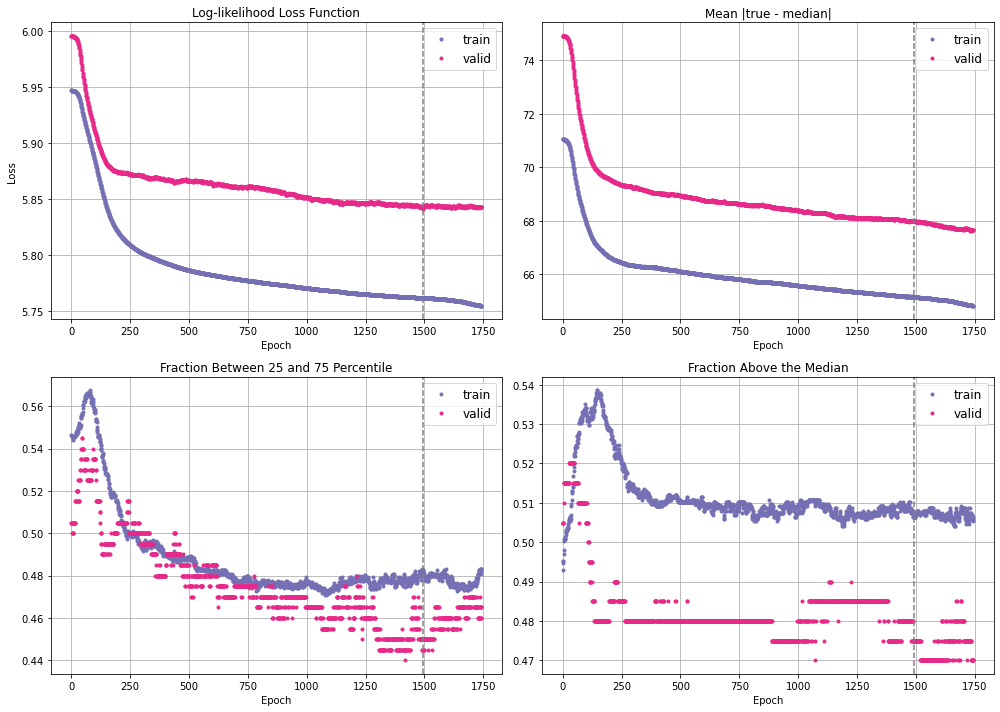

'longitude303_EPCP48_2018_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 3339.
Epoch 03589: early stopping
{'best_epoch': 3338,
 'elapsed_time': 66.1432580947876,
 'loss_train': 5.743404388427734,
 'loss_valid': 5.744653701782227,
 'network_seed': 123}


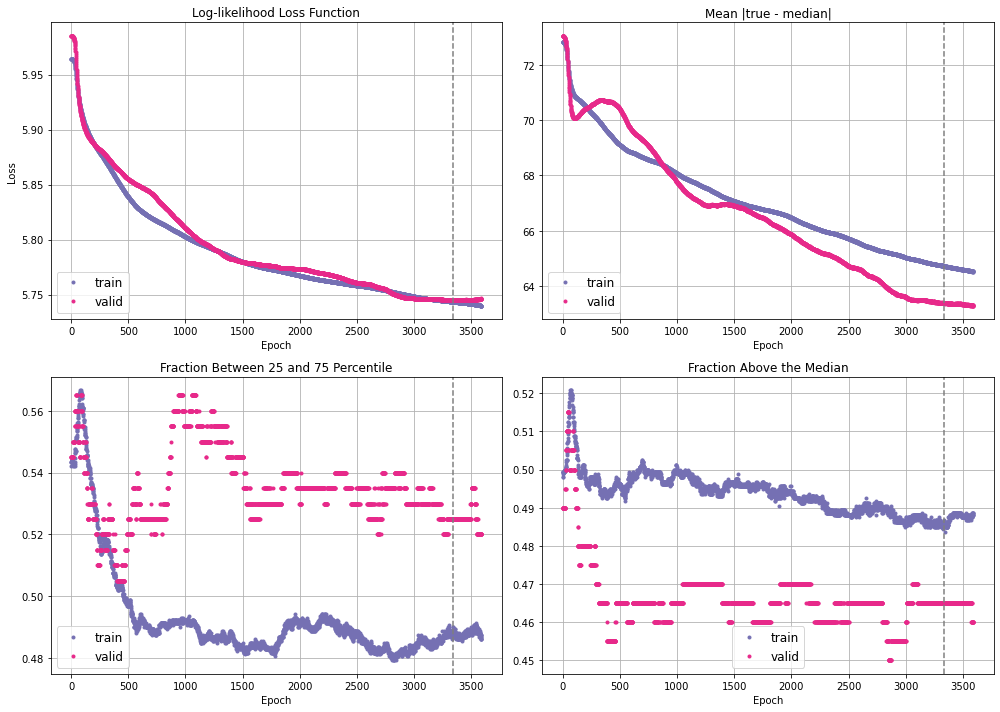

'longitude303_EPCP48_2019_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 624.
Epoch 00874: early stopping
{'best_epoch': 623,
 'elapsed_time': 18.21343207359314,
 'loss_train': 5.749859809875488,
 'loss_valid': 5.835939884185791,
 'network_seed': 123}


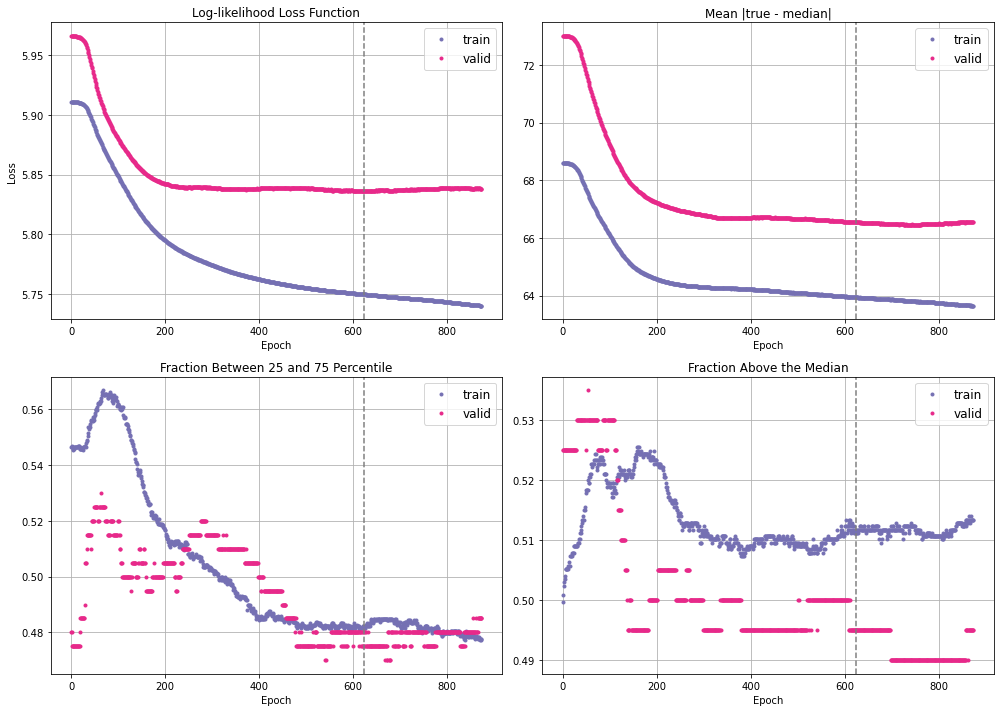

'longitude303_EPCP48_2020_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 2196.
Epoch 02446: early stopping
{'best_epoch': 2195,
 'elapsed_time': 50.050167083740234,
 'loss_train': 5.729800224304199,
 'loss_valid': 5.801588535308838,
 'network_seed': 123}


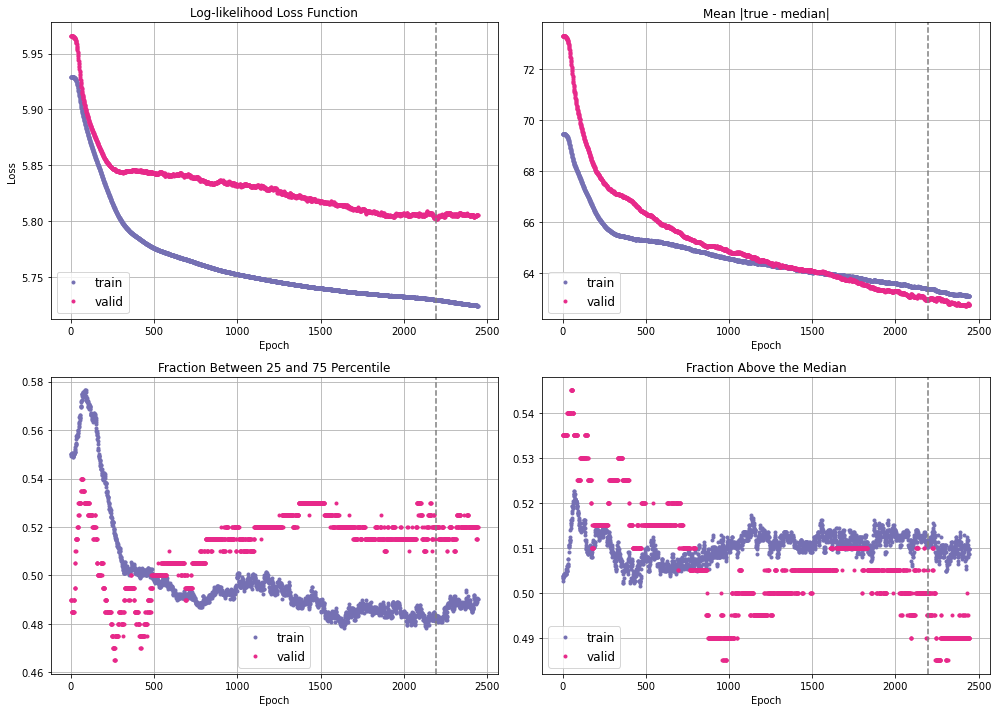

'longitude303_EPCP48_2021_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1979.
Epoch 02229: early stopping
{'best_epoch': 1978,
 'elapsed_time': 43.44730615615845,
 'loss_train': 5.732780933380127,
 'loss_valid': 5.813333034515381,
 'network_seed': 123}


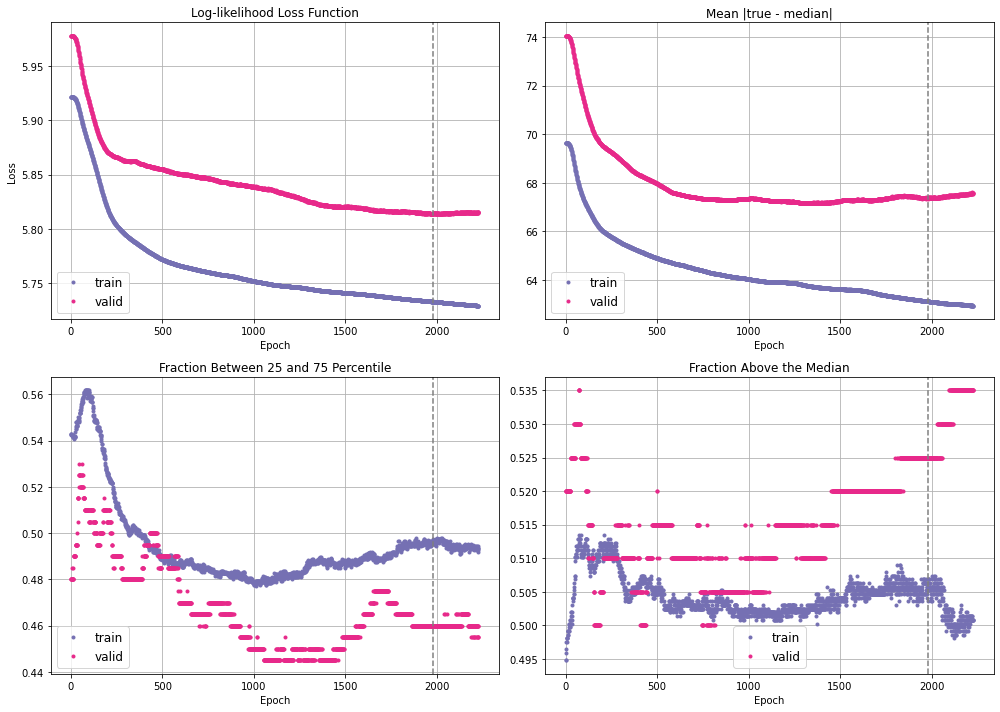

'latitude303_EPCP48_2013_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1365.
Epoch 01615: early stopping
{'best_epoch': 1364,
 'elapsed_time': 32.18873381614685,
 'loss_train': 5.600531578063965,
 'loss_valid': 5.6949381828308105,
 'network_seed': 123}


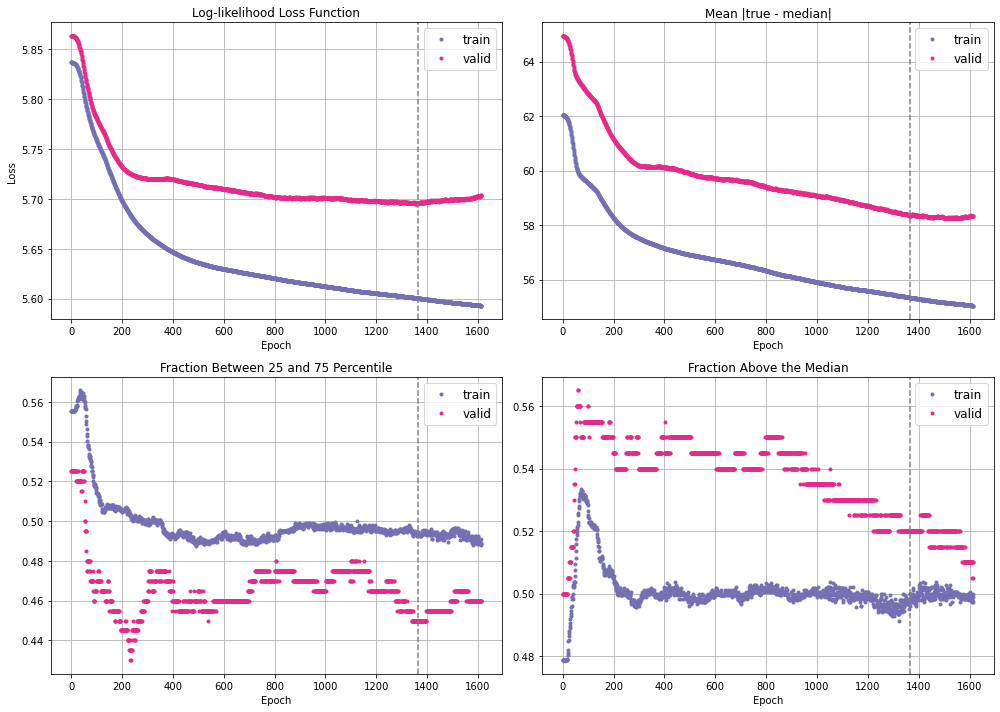

'latitude303_EPCP48_2014_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 3035.
Epoch 03285: early stopping
{'best_epoch': 3034,
 'elapsed_time': 61.57957124710083,
 'loss_train': 5.603053569793701,
 'loss_valid': 5.6507649421691895,
 'network_seed': 123}


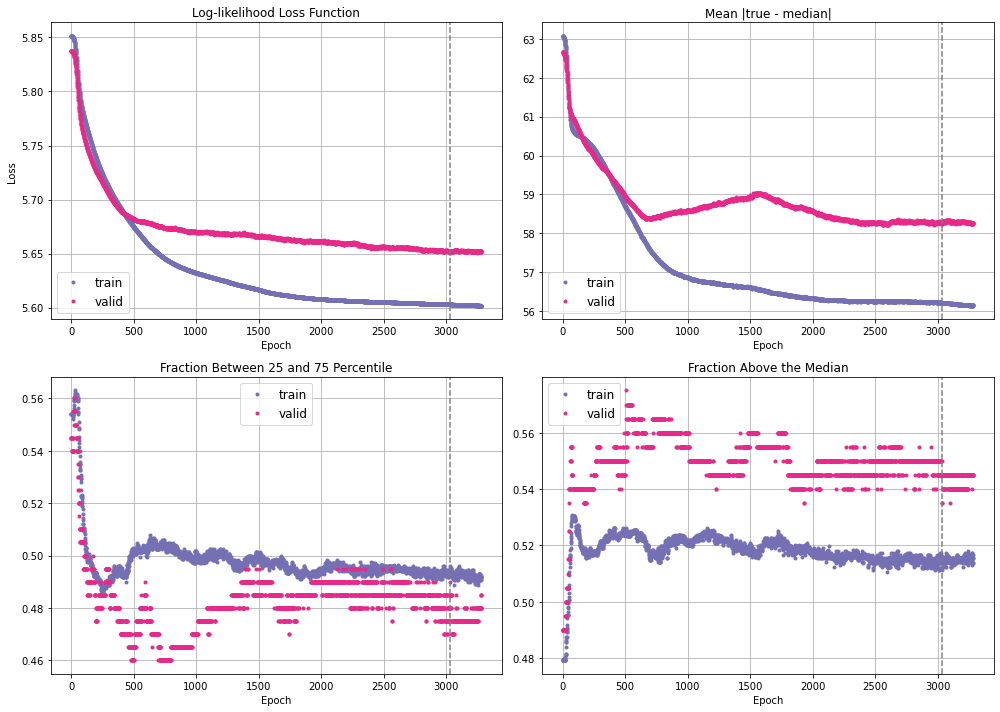

'latitude303_EPCP48_2015_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 644.
Epoch 00894: early stopping
{'best_epoch': 643,
 'elapsed_time': 16.508392095565796,
 'loss_train': 5.608048439025879,
 'loss_valid': 5.6924662590026855,
 'network_seed': 123}


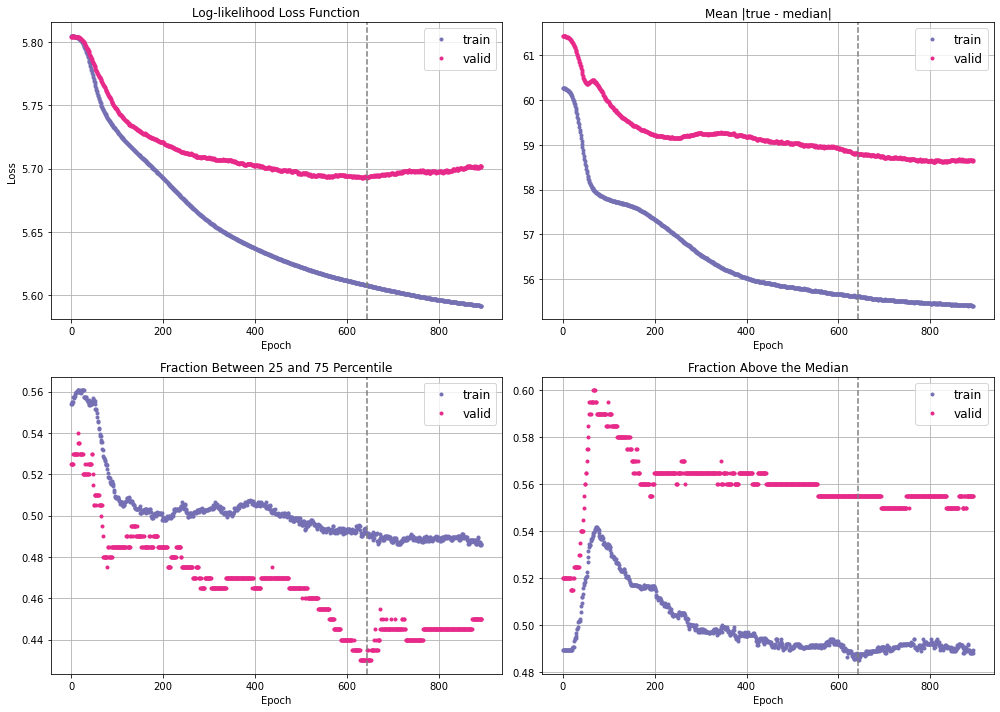

'latitude303_EPCP48_2016_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 394.
Epoch 00644: early stopping
{'best_epoch': 393,
 'elapsed_time': 12.671968936920166,
 'loss_train': 5.725778579711914,
 'loss_valid': 5.726761341094971,
 'network_seed': 123}


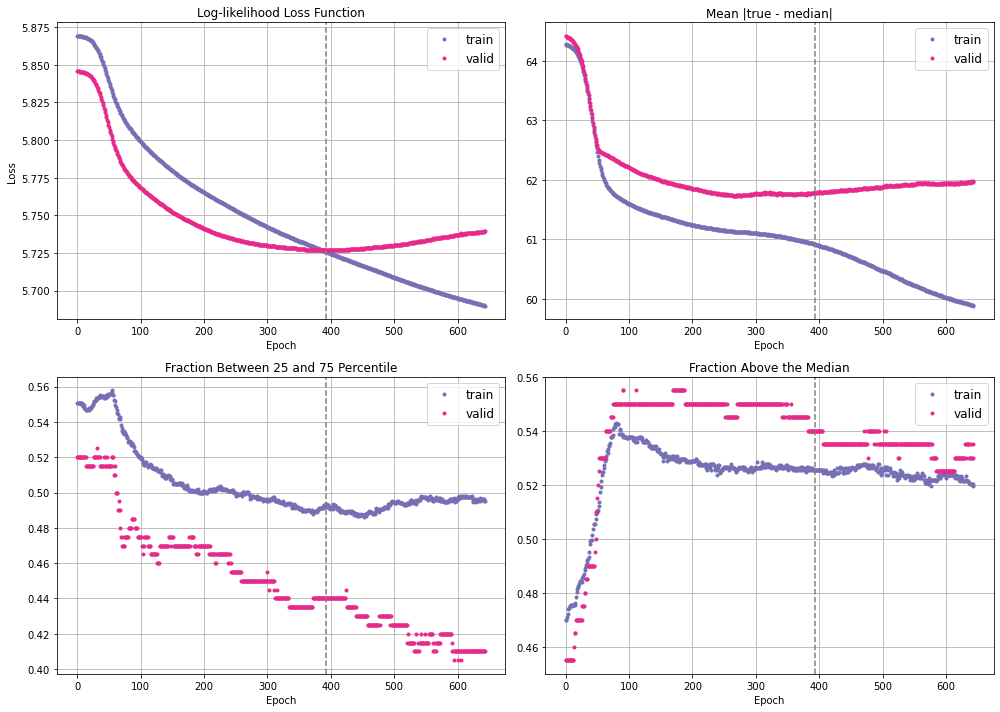

'latitude303_EPCP48_2017_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 541.
Epoch 00791: early stopping
{'best_epoch': 540,
 'elapsed_time': 15.970357894897461,
 'loss_train': 5.638719081878662,
 'loss_valid': 5.6656999588012695,
 'network_seed': 123}


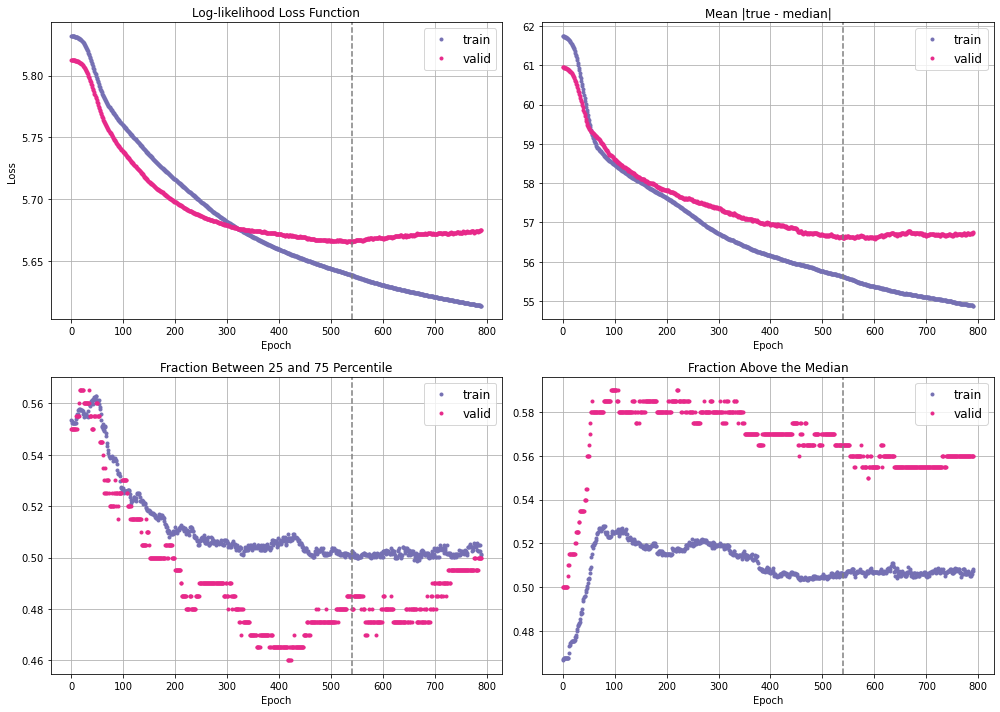

'latitude303_EPCP48_2018_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 2488.
Epoch 02738: early stopping
{'best_epoch': 2487,
 'elapsed_time': 49.759289264678955,
 'loss_train': 5.607149124145508,
 'loss_valid': 5.719735145568848,
 'network_seed': 123}


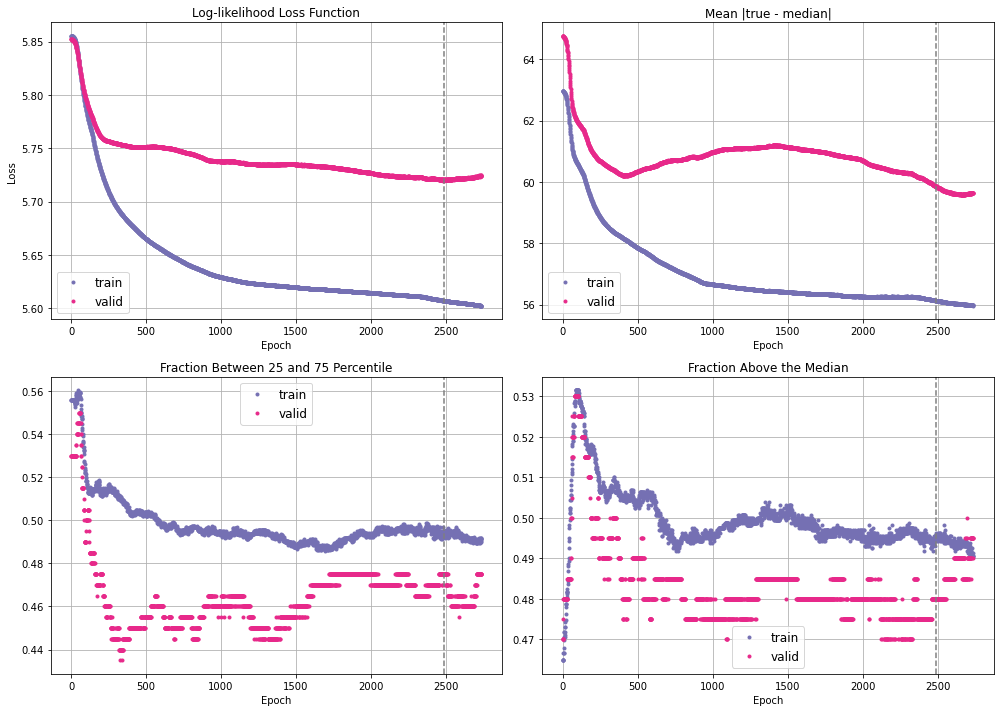

'latitude303_EPCP48_2019_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 877.
Epoch 01127: early stopping
{'best_epoch': 876,
 'elapsed_time': 22.47104787826538,
 'loss_train': 5.609673023223877,
 'loss_valid': 5.667590141296387,
 'network_seed': 123}


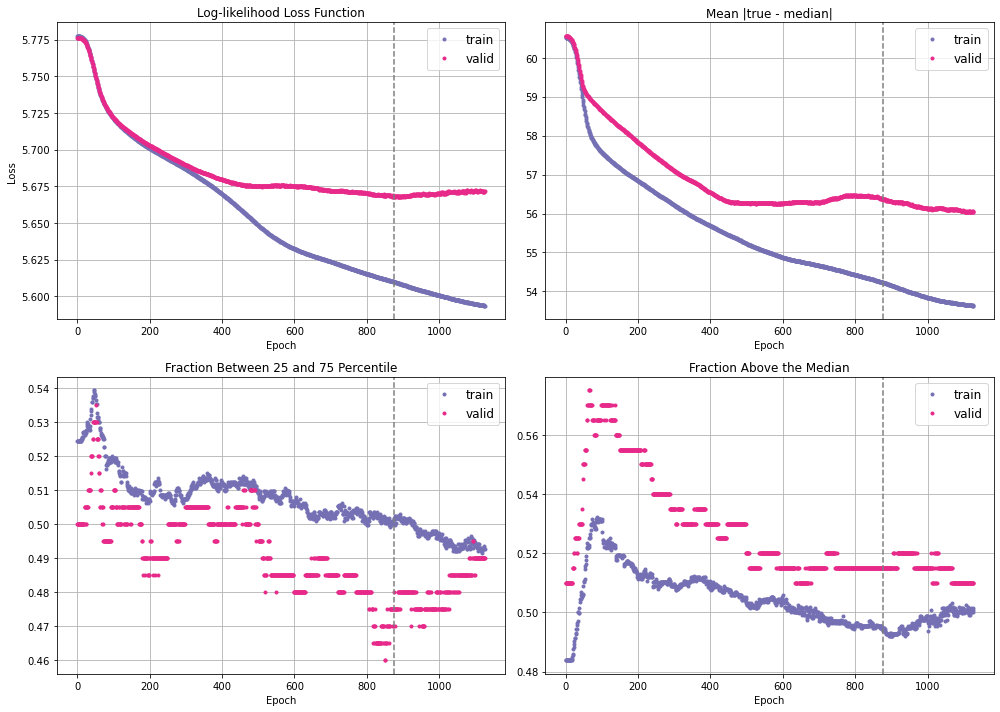

'latitude303_EPCP48_2020_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 613.
Epoch 00863: early stopping
{'best_epoch': 612,
 'elapsed_time': 17.66507601737976,
 'loss_train': 5.657510757446289,
 'loss_valid': 5.729823112487793,
 'network_seed': 123}


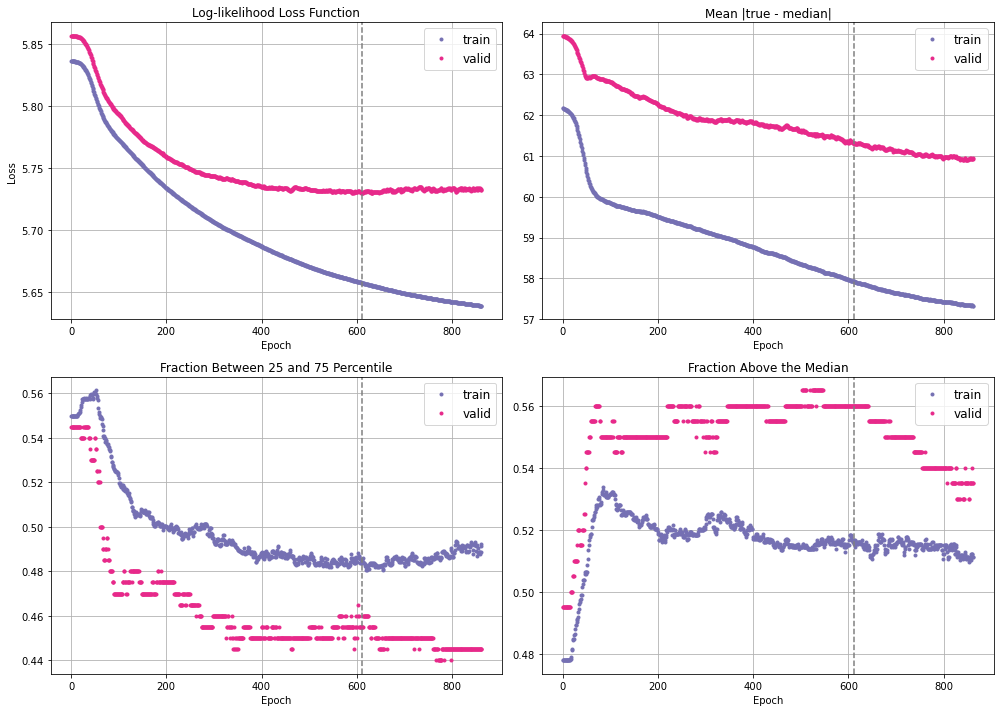

'latitude303_EPCP48_2021_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1760.
Epoch 02010: early stopping
{'best_epoch': 1759,
 'elapsed_time': 39.501643896102905,
 'loss_train': 5.6194305419921875,
 'loss_valid': 5.7114481925964355,
 'network_seed': 123}


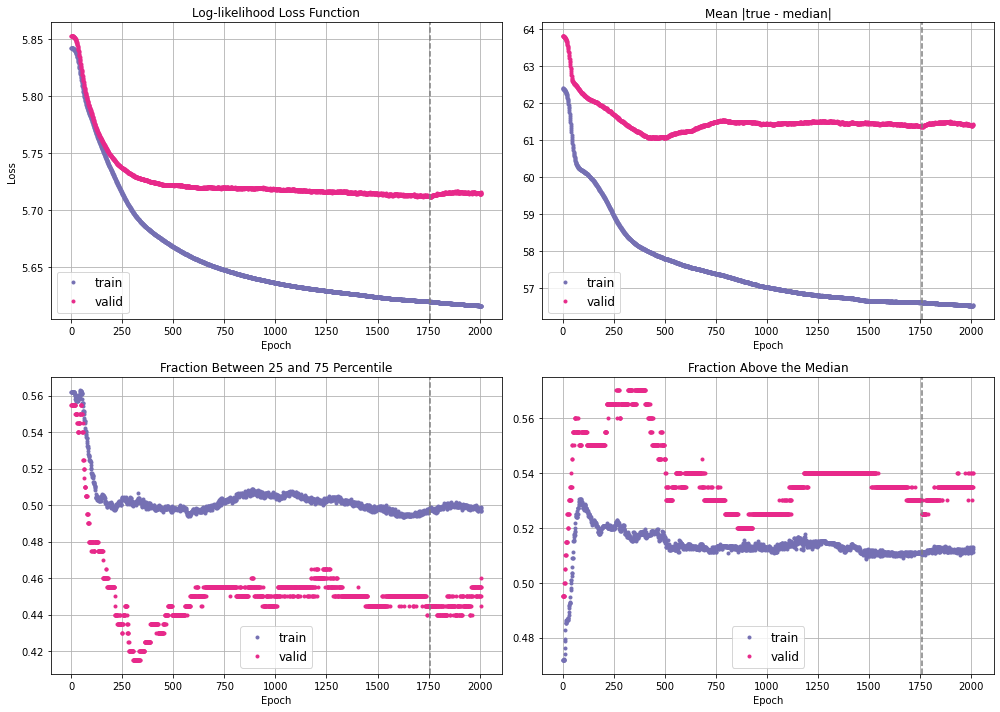

In [4]:
imp.reload(build_model)

for exp_name in EXP_NAME_LIST:
    settings = experiment_settings.get_settings(exp_name)

    # set testing data
    if settings["test_condition"] == "leave-one-out":
        TESTING_YEARS_LIST = np.arange(2013,2022)
    elif settings["test_condition"] == "years":
        TESTING_YEARS_LIST = (np.copy(settings["years_test"]))
    else:
        raise NotImplementError('no such testing condition')
        
    for testing_years in TESTING_YEARS_LIST:        
        # set testing year
        settings["years_test"] = (testing_years,)
        
        
        for rng_seed in settings['rng_seed_list']:
            settings['rng_seed'] = rng_seed

            # build the intensity data tensors
            (
                data_summary,        
                x_train,
                onehot_train,
                x_val,
                onehot_val,
                x_test,
                onehot_test,        
                x_valtest,
                onehot_valtest,
                df_train,
                df_val,
                df_test,
                df_valtest,
            ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

            # define the callbacks
            earlystoping_callback = tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=settings["patience"],
                restore_best_weights=True,
                verbose=1,
            )

            training_callback = TrainingInstrumentation(
                x_train,
                onehot_train,
                interval=50,
            )

            callbacks = [earlystoping_callback, 
                         # training_callback,
                        ]

            # set network seed and train the model
            NETWORK_SEED_LIST = [settings["rng_seed"]]

            for network_seed in NETWORK_SEED_LIST:
                
                # set random seeds
                np.random.seed(rng_seed)
                random.seed(rng_seed)                            
                tf.random.set_seed(network_seed) 

                # Create the model name.
                model_name = (
                    exp_name + "_" + 
                    str(testing_years) + '_' +
                    settings["uncertainty_type"] + '_' + 
                    f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
                )
                pprint.pprint(model_name)

                # Make, compile, and train the model
                tf.keras.backend.clear_session()            
                model = build_model.make_model(
                    settings,
                    x_train,
                    onehot_train,
                    model_compile=True,
                )   
                # model.summary()

                # check if the model exists
                model_savename = MODEL_PATH + model_name + "_weights.h5"
                if os.path.exists(model_savename) and OVERWRITE_MODEL==False:
                    print(model_savename + 'exists. Skipping...')
                    continue

                # train the network
                start_time = time.time()
                history = model.fit(
                    x_train,
                    onehot_train,
                    validation_data=(x_val, onehot_val),
                    batch_size=settings["batch_size"],
                    epochs=settings["n_epochs"],
                    shuffle=True,
                    verbose=0,
                    callbacks=callbacks,
                )
                stop_time = time.time()

                # Display the results, and save the model rum.
                best_epoch = np.argmin(history.history["val_loss"])
                fit_summary = {
                    "network_seed": network_seed,
                    "elapsed_time": stop_time - start_time,
                    "best_epoch": best_epoch,
                    "loss_train": history.history["loss"][best_epoch],
                    "loss_valid": history.history["val_loss"][best_epoch],
                }
                pprint.pprint(fit_summary, width=80)
                plot_history(history, model_name)

                save_model_run(
                    data_summary,
                    fit_summary,
                    model,
                    MODEL_PATH,
                    model_name,
                    settings,
                    __version__,
                )

In [5]:
2+2

4